# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Juliette Whelan
* Username: jrwhelan
* Student number: s6211860
* Group (AS1, etc.): AS3

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

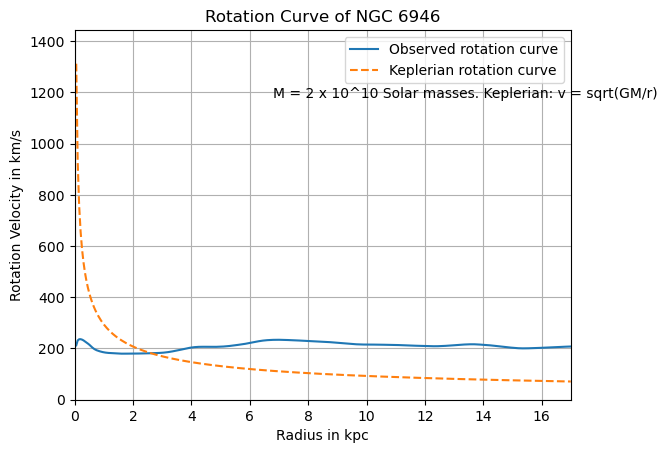

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G

# Constants

M_sun = 1.989e30              # mass of the Sun in kg
M = 2e10 * M_sun              # stellar mass of NGC 6946 in kg
kpc_to_m = 3.086e19           # 1 kpc in meters
m_per_km = 1000                # 1 km in meters

# Load observational data

data = np.loadtxt("rotcur.dat.txt")

# Remove rows where radius is 0
data = data[data[:, 0] > 0]

radius = data[:, 0]       # radius in kpc
velocity = data[:, 1]     # velocity in km/s

# Keplerian curve

radius_m = radius * kpc_to_m
v_kepler_kms = np.sqrt(G*M / (radius_m)) / m_per_km

# Save and reload Keplerian curve

kepler_data = np.column_stack((radius, v_kepler_kms))
np.savetxt("keplerian_curve.txt", kepler_data, header="Radius(kpc)  Velocity(km/s)")

kepler_loaded = np.loadtxt("keplerian_curve.txt")
radius_kep = kepler_loaded[:, 0]
velocity_kep = kepler_loaded[:, 1]

# Plot Keplerian curve
plt.plot(radius,     velocity,     label="Observed rotation curve")
plt.plot(radius_kep, velocity_kep, linestyle="--", label="Keplerian rotation curve")

# Axis limits

plt.xlim(0, np.max(radius_kep))
plt.ylim(0, max(np.max(velocity), np.max(velocity_kep)) * 1.1)

# Labels and annotation

plt.xlabel("Radius in kpc")
plt.ylabel("Rotation Velocity in km/s")
plt.title("Rotation Curve of NGC 6946")

plt.text(0.4*np.max(radius), 0.9*np.max(velocity_kep), "M = 2 x 10^10 Solar masses. Keplerian: v = sqrt(GM/r)")

plt.legend()
plt.grid()

plt.show()

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

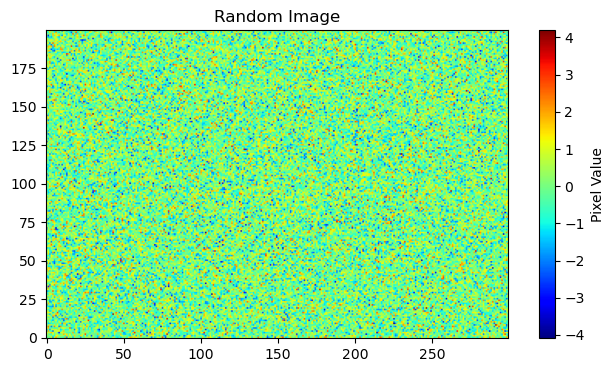

Slice mean: 0.005354787812838655
Slice standard deviation: 1.0394001585619126
These are the expected values as the mean is close to 0 and the std close to 1.


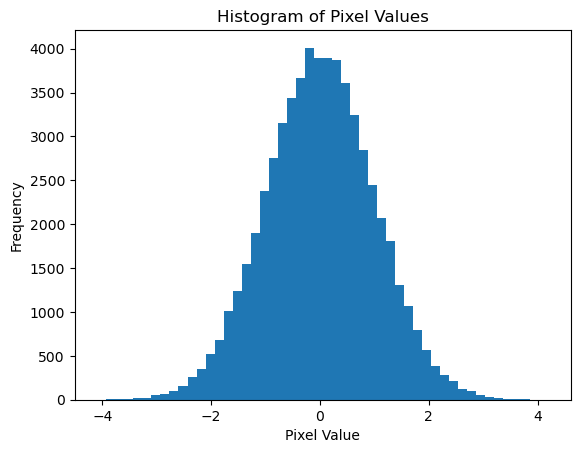

We recognize a normal distribution with a bell-shaped curve and a symetry around zero.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Create 2D numpy array of 200x300

image = np.random.normal(0, 1.0, (200, 300))

# Plot the image

plt.figure(figsize=(8, 4))
plt.imshow(image, cmap='jet', origin='lower')
plt.colorbar(label="Pixel Value")
plt.title("Random Image")
plt.show()

# Take a 30x30 slice

slice_30 = image[50:80, 100:130]   # example of a slice

mean_slice = np.mean(slice_30)
std_slice = np.std(slice_30)

print(f"Slice mean: {mean_slice}")
print(f"Slice standard deviation: {std_slice}")
print("These are the expected values as the mean is close to 0 and the std close to 1.")

# Histogram of all image values in 50 bins

plt.figure()
plt.hist(image.ravel(), bins=50)
plt.title("Histogram of Pixel Values")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

print("We recognize a normal distribution with a bell-shaped curve and a symetry around zero.")

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

AstroEllipse: Center = (0, 0) Semi-major axis = 3 Semi-minor axis = 2 Position angle = 45 deg
Area: 18.84955592153876
Perimeter: 15.865437575563961


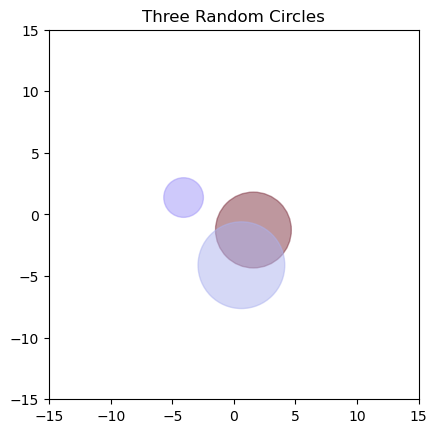

In [6]:
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib.pyplot as plt
import math

# AstroEllipse class
class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert(semi_major >= semi_minor)
        self.a = semi_major
        self.b = semi_minor

        XY = (xc, yc)
        angle_mpl = position_angle
        height = 2.0 * self.a
        width  = 2.0 * self.b
        super().__init__(XY, width, height, angle=angle_mpl, **args)

    def area(self):
        return math.pi * self.a * self.b  # Calculate Area of ellipse

    def perimeter(self):
        a = self.a
        b = self.b
        return math.pi * (3*(a + b) - math.sqrt((3*a + b)*(a + 3*b)))  # Calculate Perimeter of ellipse using Ramanujan's first formula

    def __str__(self):
        center = self.get_center()  
        return (f"AstroEllipse:"
                f" Center = ({center[0]}, {center[1]})"
                f" Semi-major axis = {self.a}"
                f" Semi-minor axis = {self.b}"
                f" Position angle = {self.angle} deg")

# Example Ellipse with semi-major 3 and semi-minor 2

ellipse = AstroEllipse(xc=0, yc=0, semi_major=3, semi_minor=2, position_angle=45, fill=False)
print(ellipse)
print(f"Area: {ellipse.area()}")
print(f"Perimeter: {ellipse.perimeter()}")

# MyCircle class

class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **args):
        super().__init__(xc, yc, radius, radius, 0, **args)
        self.radius = radius

# Plot 3 random circles

fig, ax = plt.subplots()
for i in range(3):
    rx = np.random.uniform(-5, 5)
    ry = np.random.uniform(-5, 5)
    r  = np.random.uniform(1, 4)
    circle = MyCircle(rx, ry, r, color=np.random.rand(3,), alpha=0.5)
    
    ax.add_patch(circle)

ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.set_aspect('equal')
plt.title("Three Random Circles")

plt.show()

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

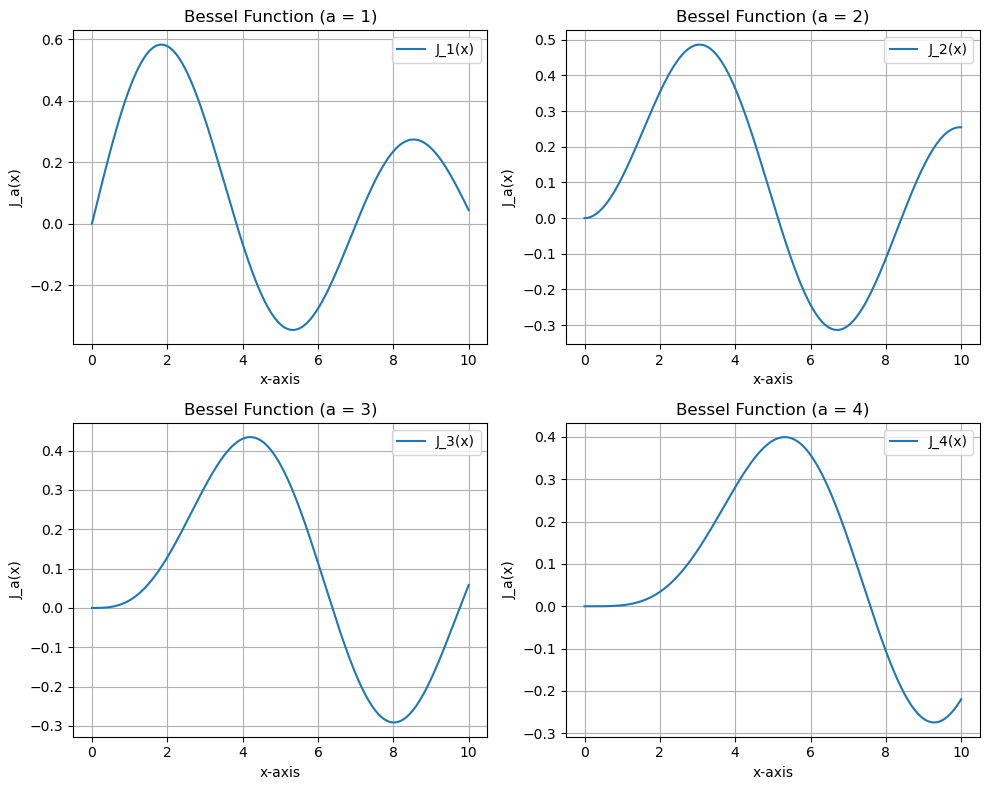

In [8]:
from scipy.special import jv
import numpy as np
import matplotlib.pyplot as plt

# Data

x = np.linspace(0, 10, 1000)
orders = [1, 2, 3, 4]

# Create 2x2 mosaic (OO style)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

for i, a in enumerate(orders):
    y = jv(a, x)
    
    axs[i].plot(x, y, label=f"J_{a}(x)")
    axs[i].set_title(f"Bessel Function (a = {a})")
    axs[i].set_xlabel("x-axis")
    axs[i].set_ylabel("J_a(x)")
    axs[i].legend()
    axs[i].grid(True)

# To prevent overlap

plt.tight_layout()

# Save transparent PNG

fig.savefig("bessel.png", transparent=True, dpi=300)

plt.show()


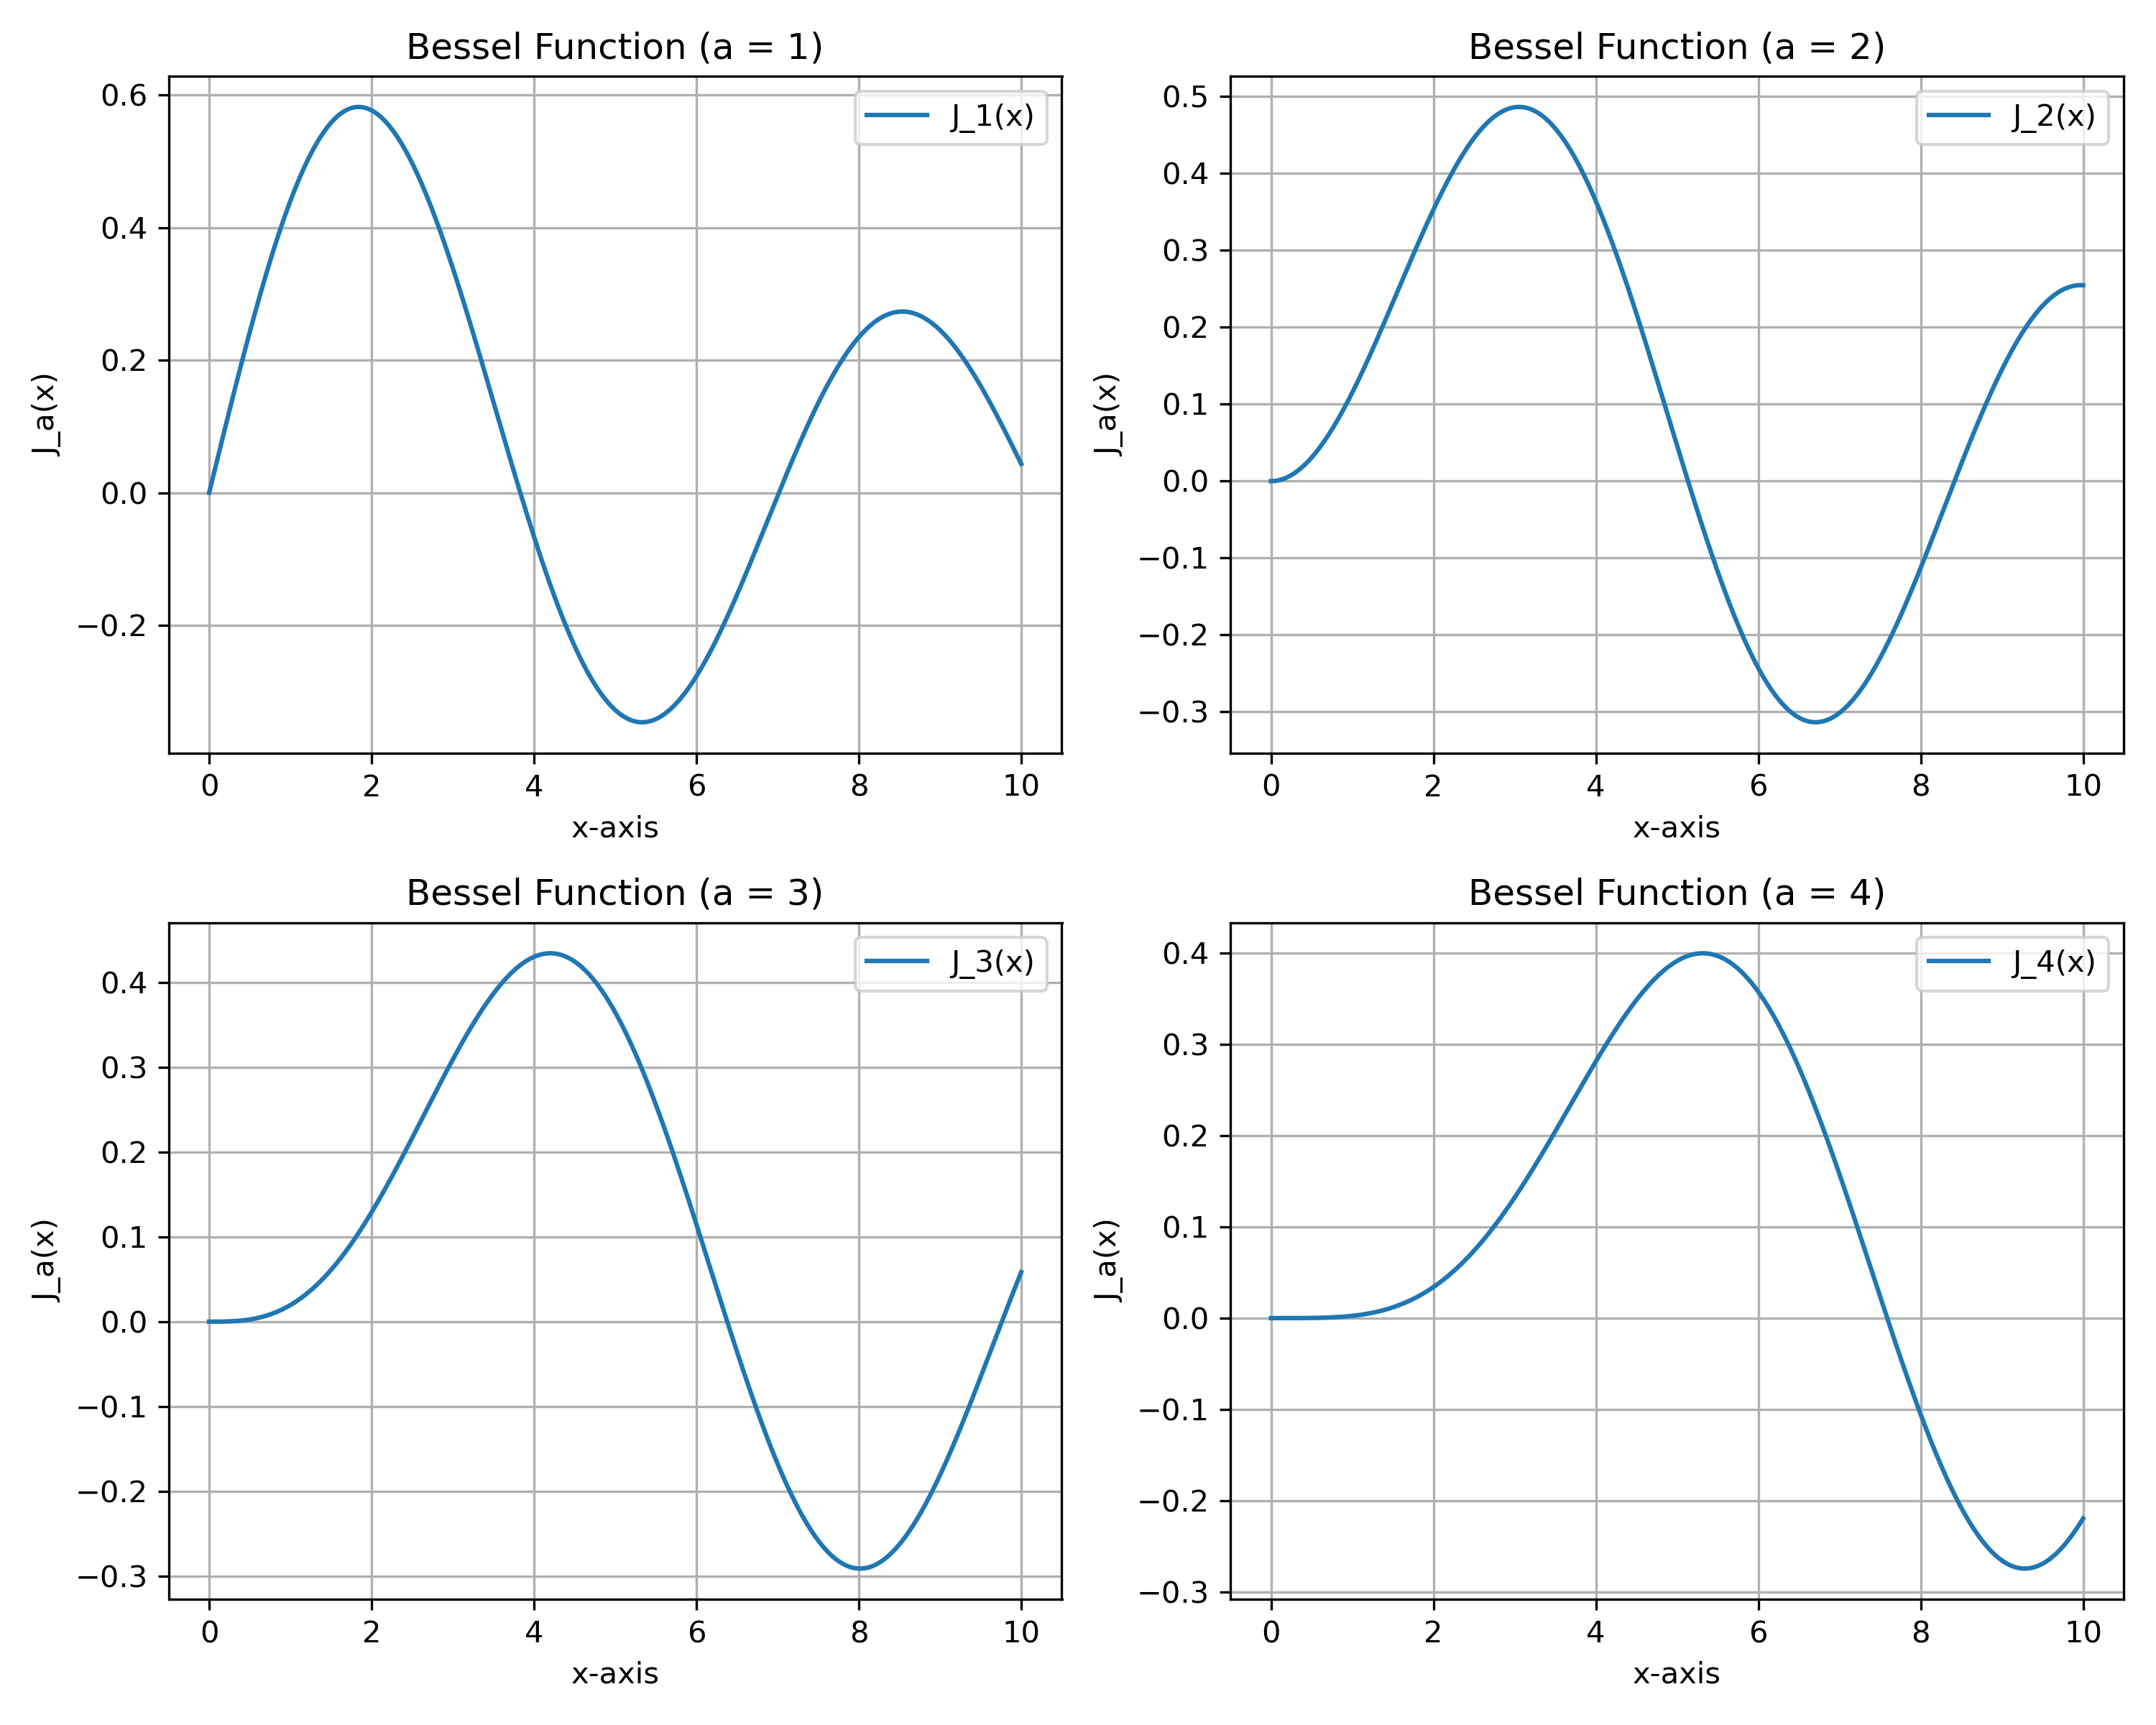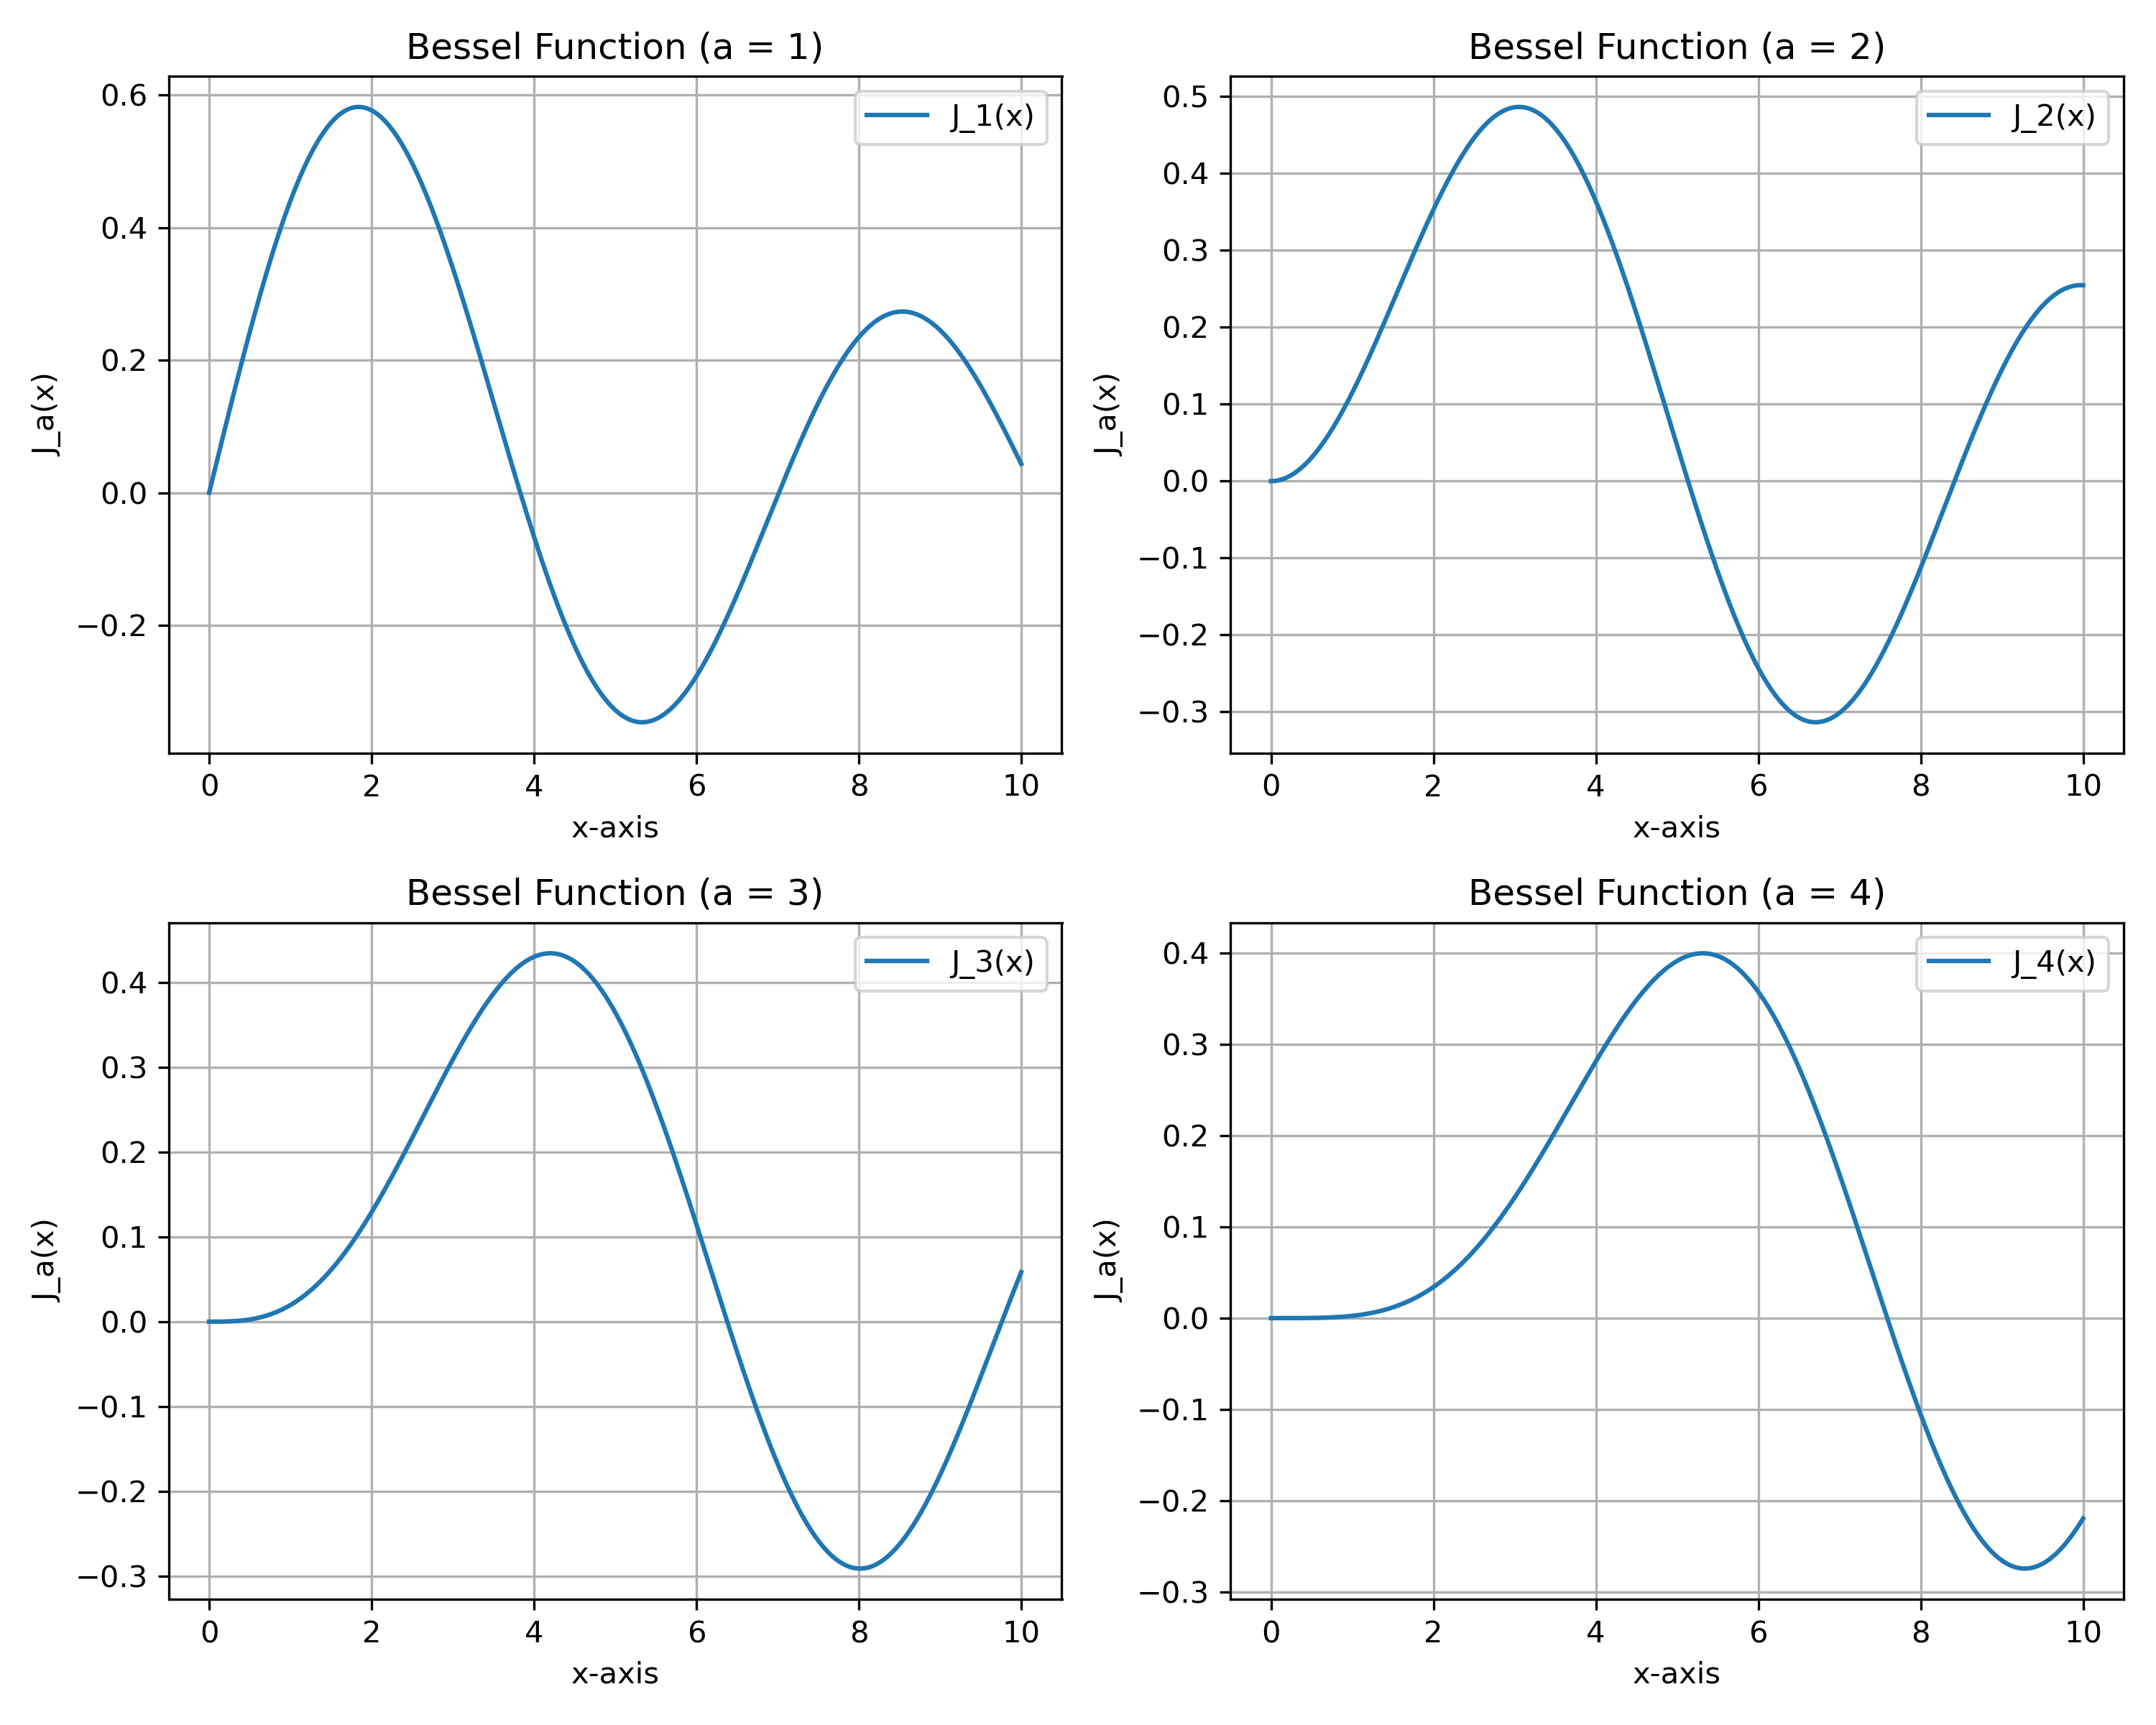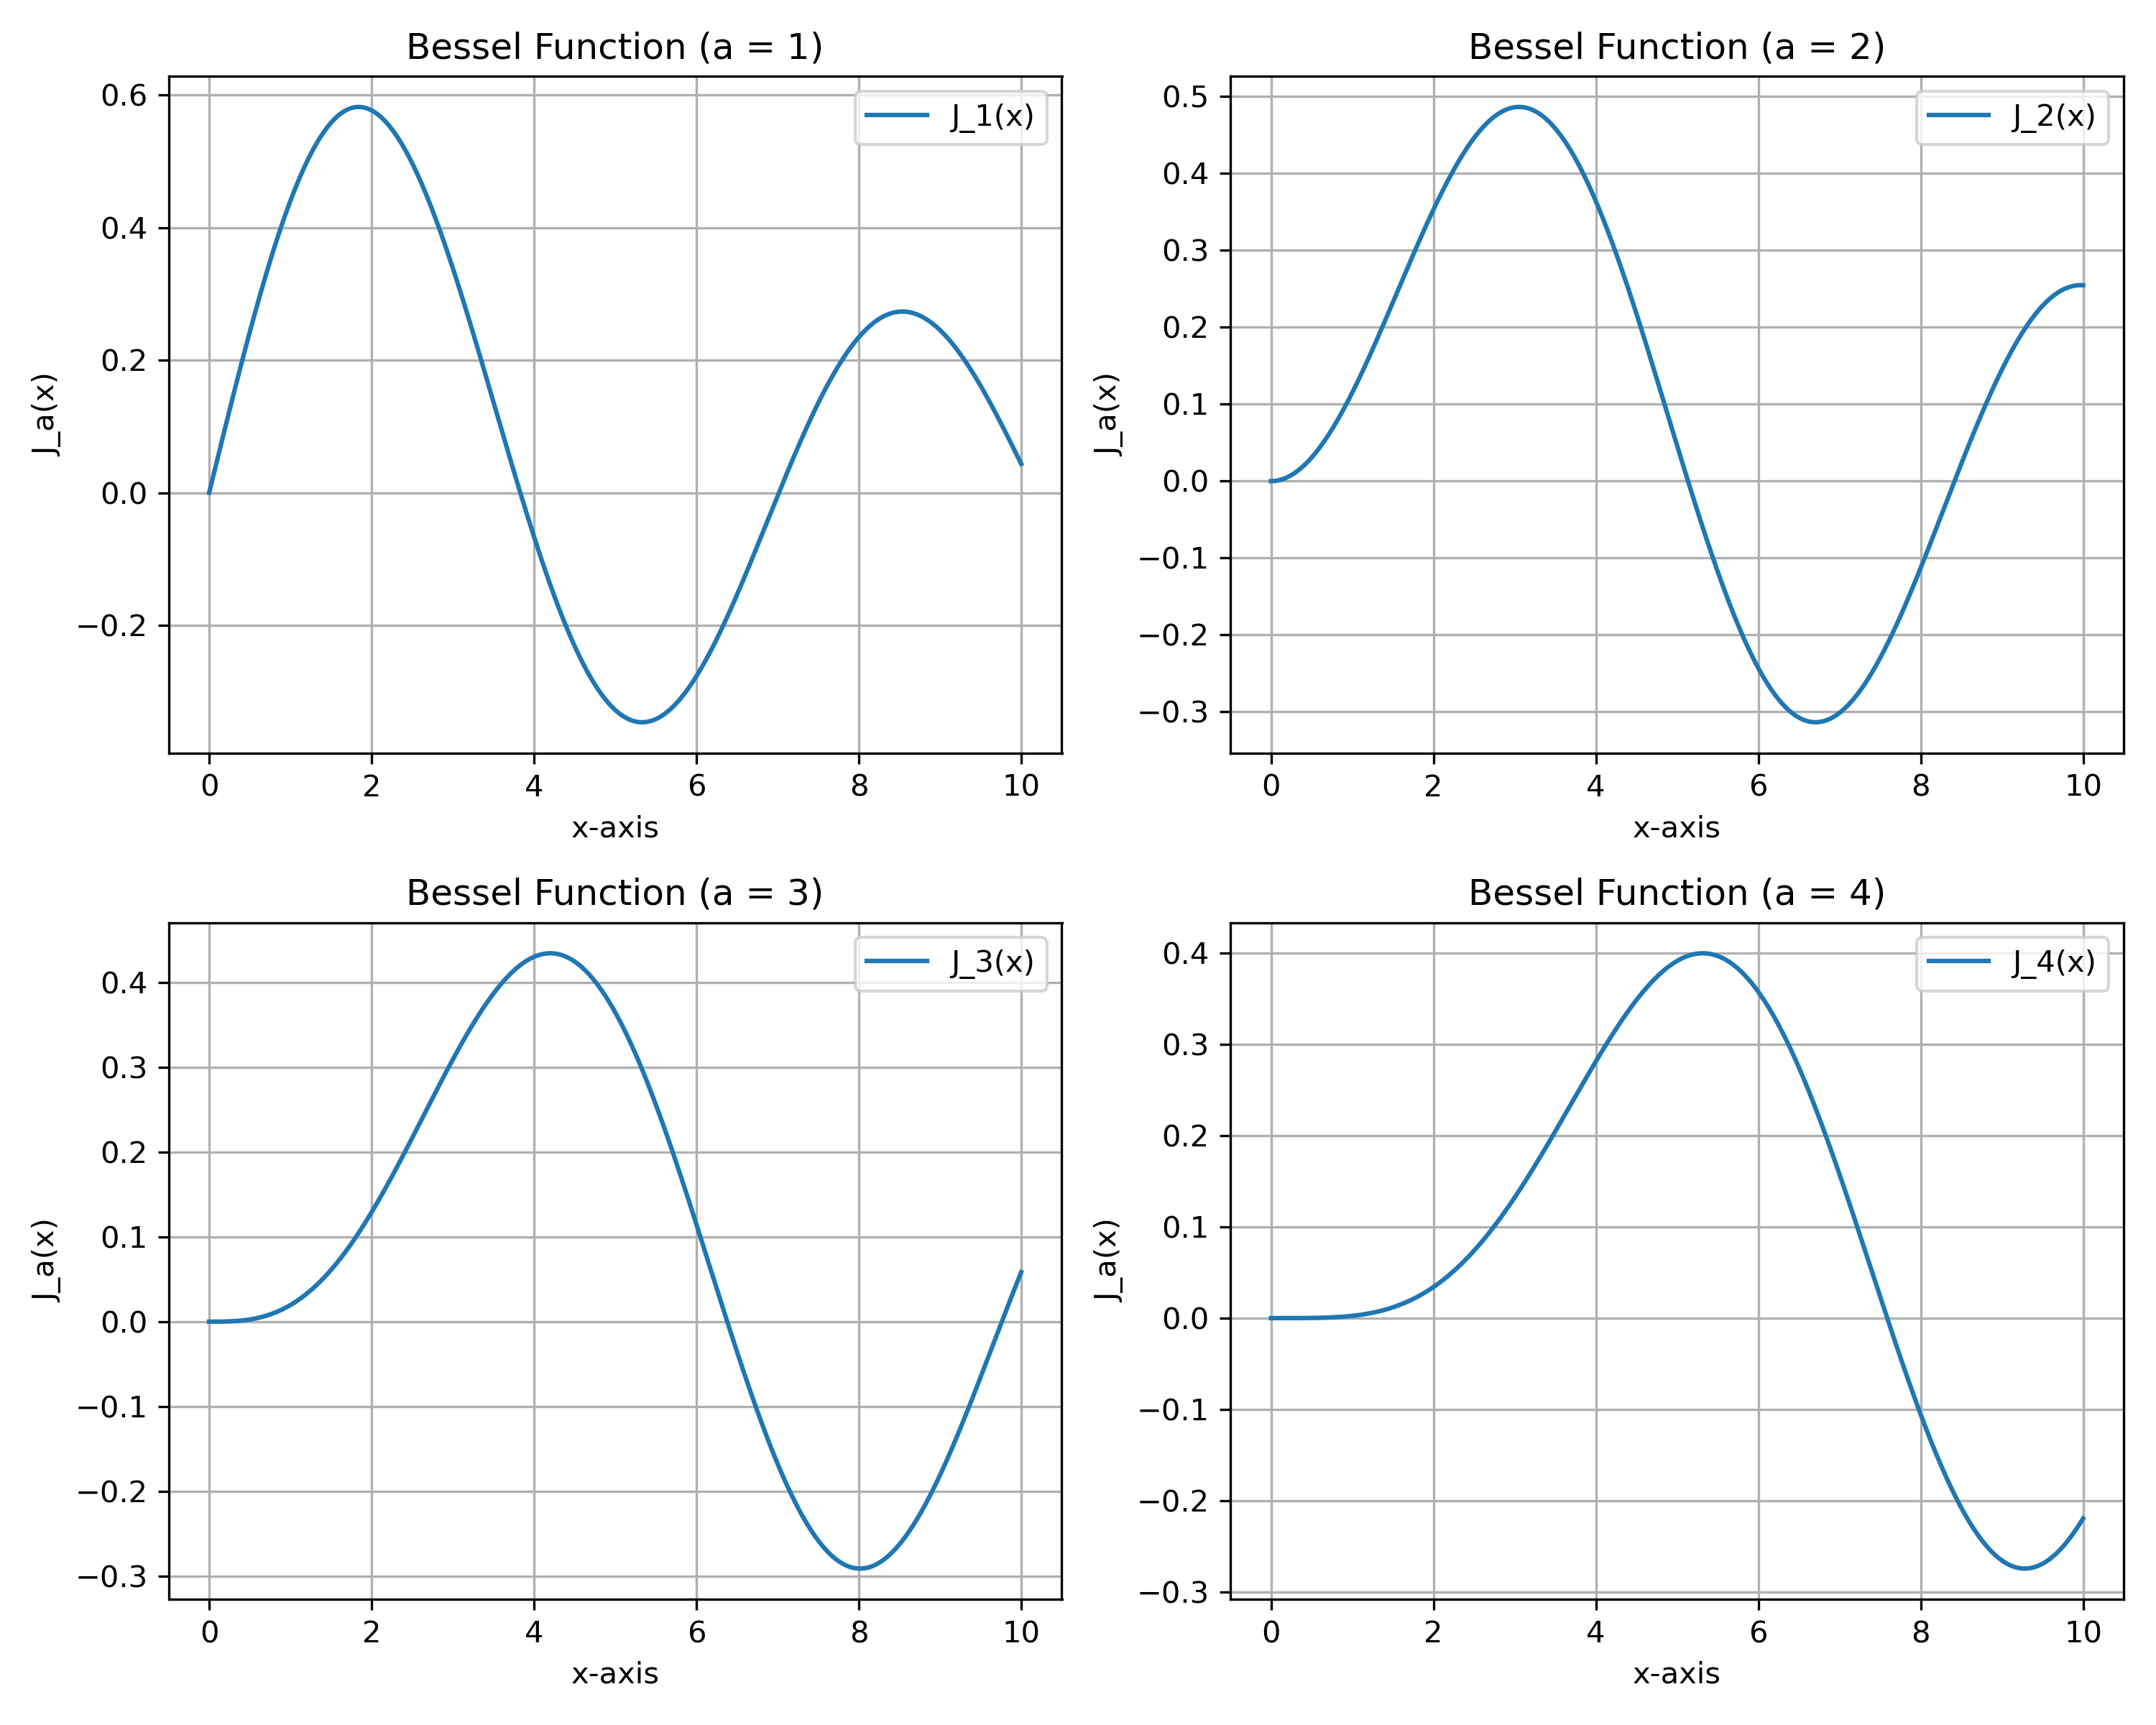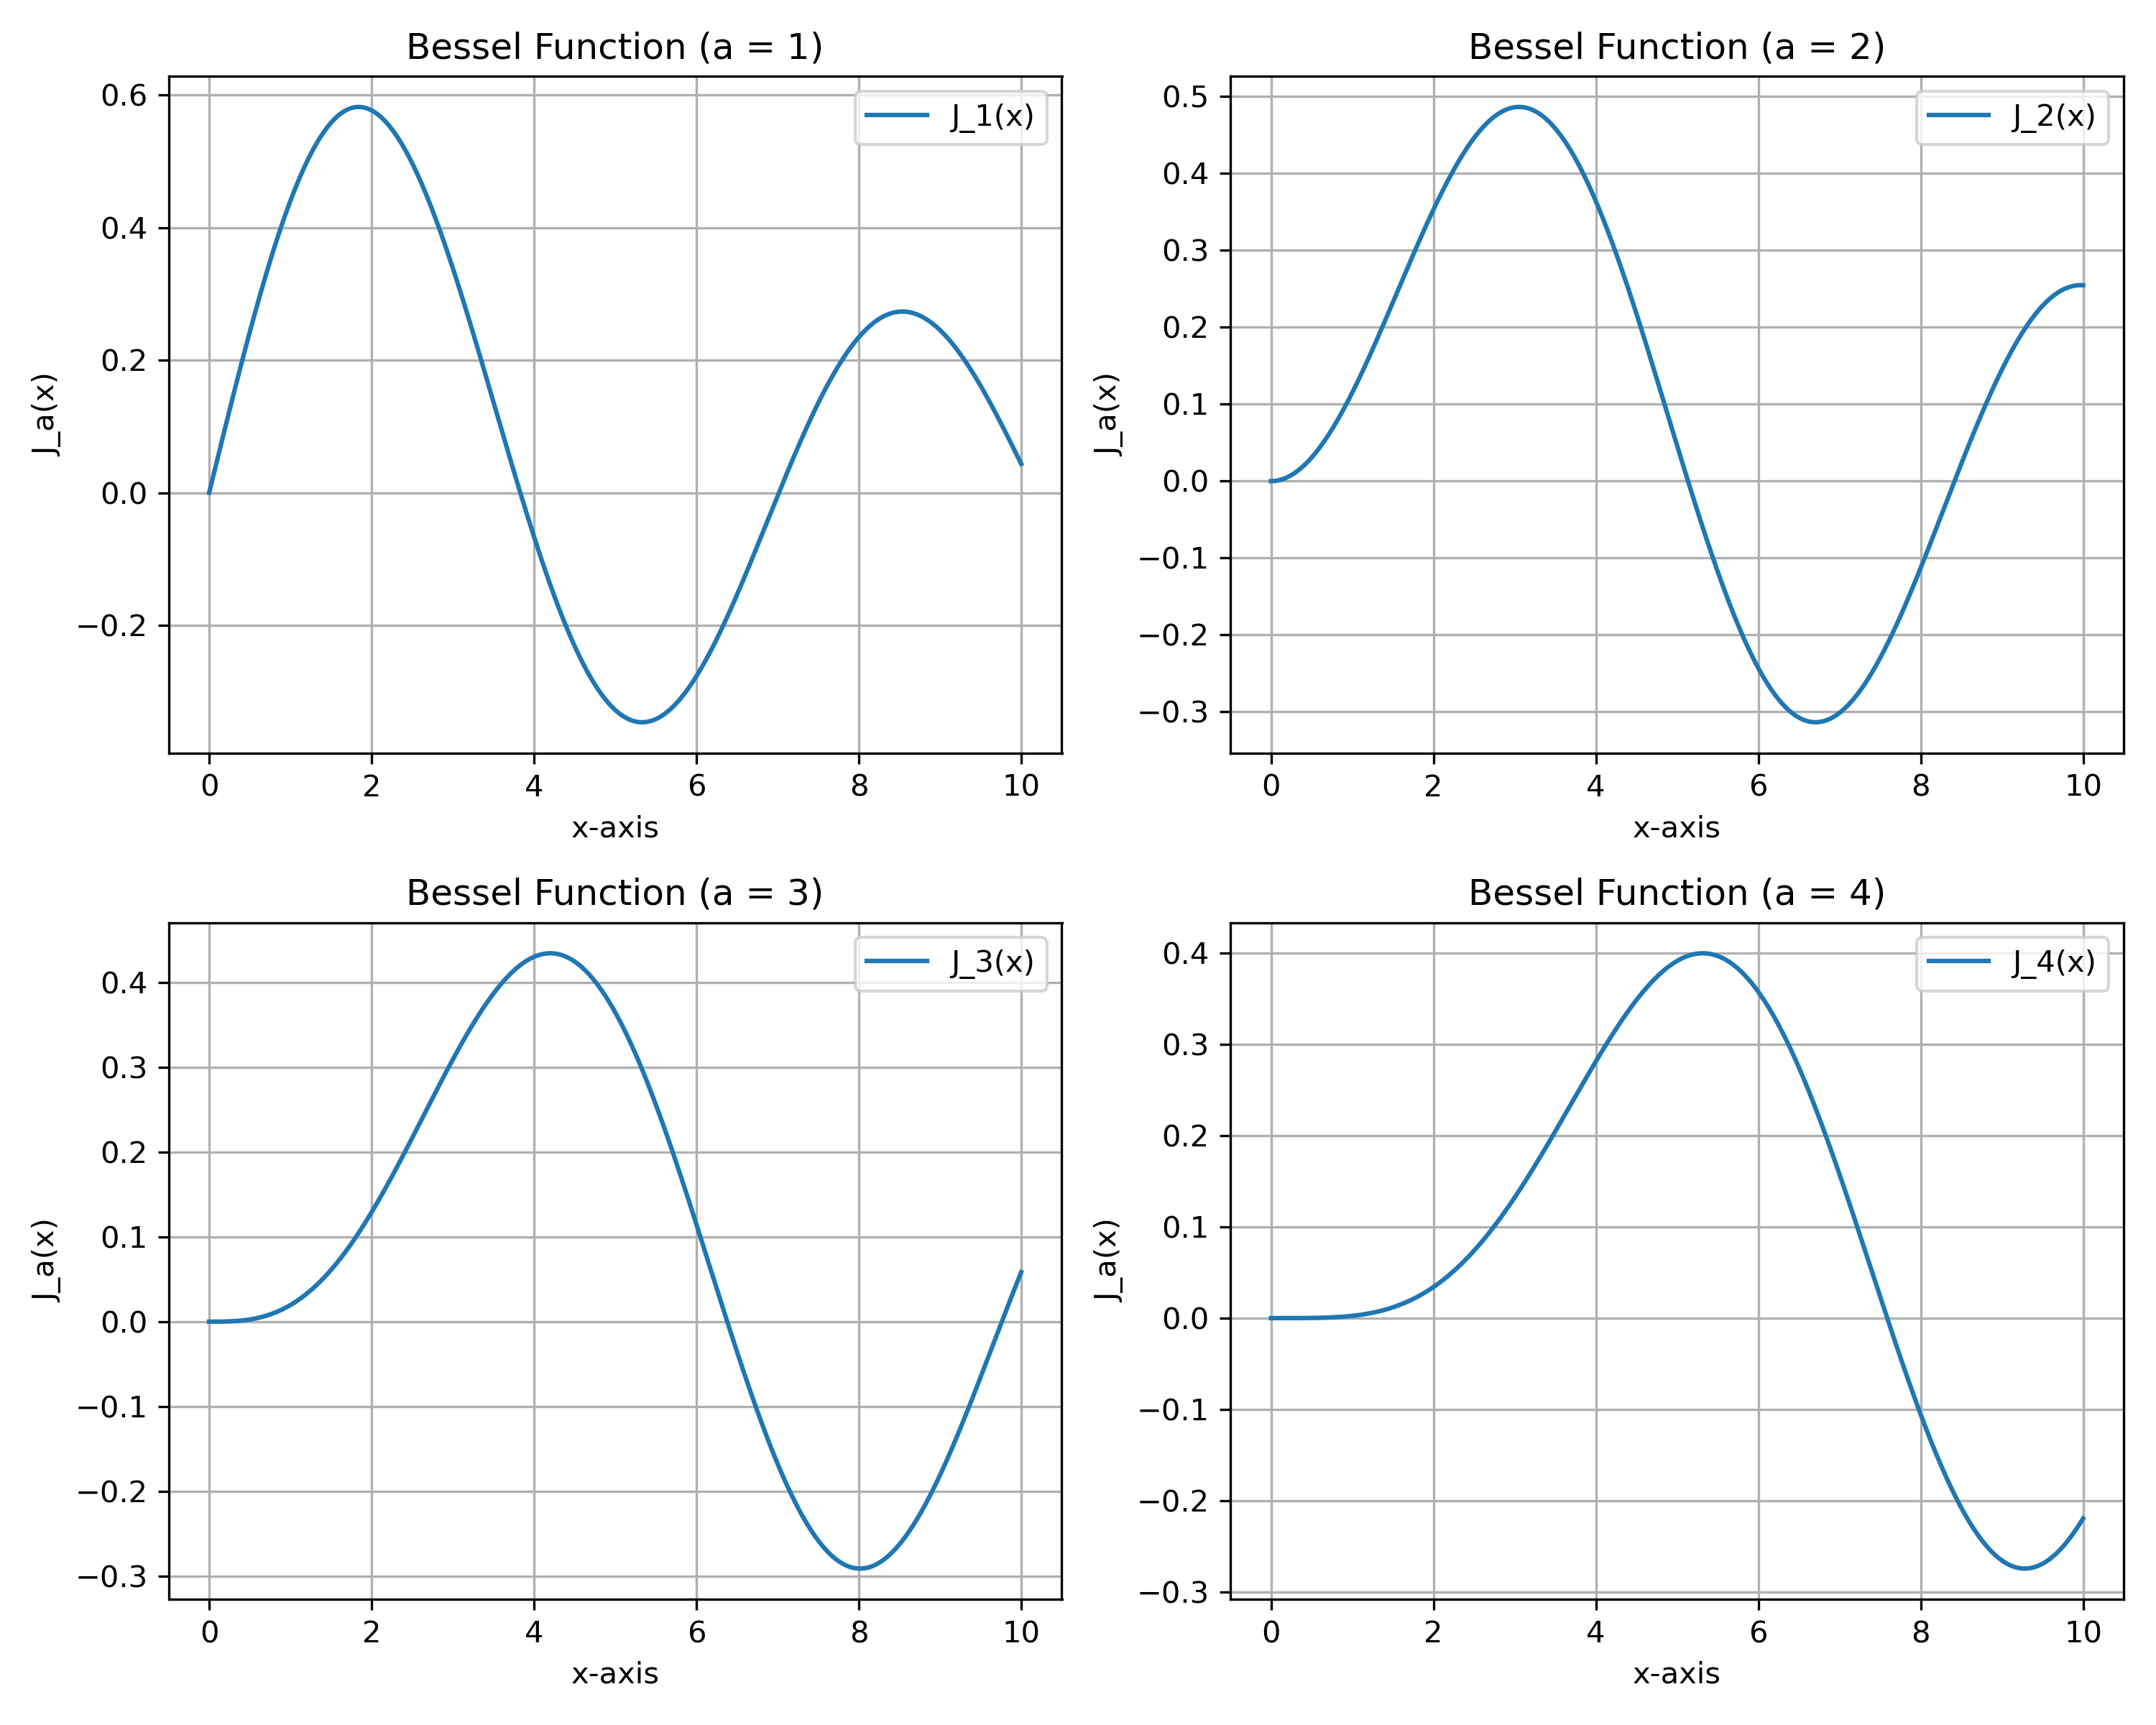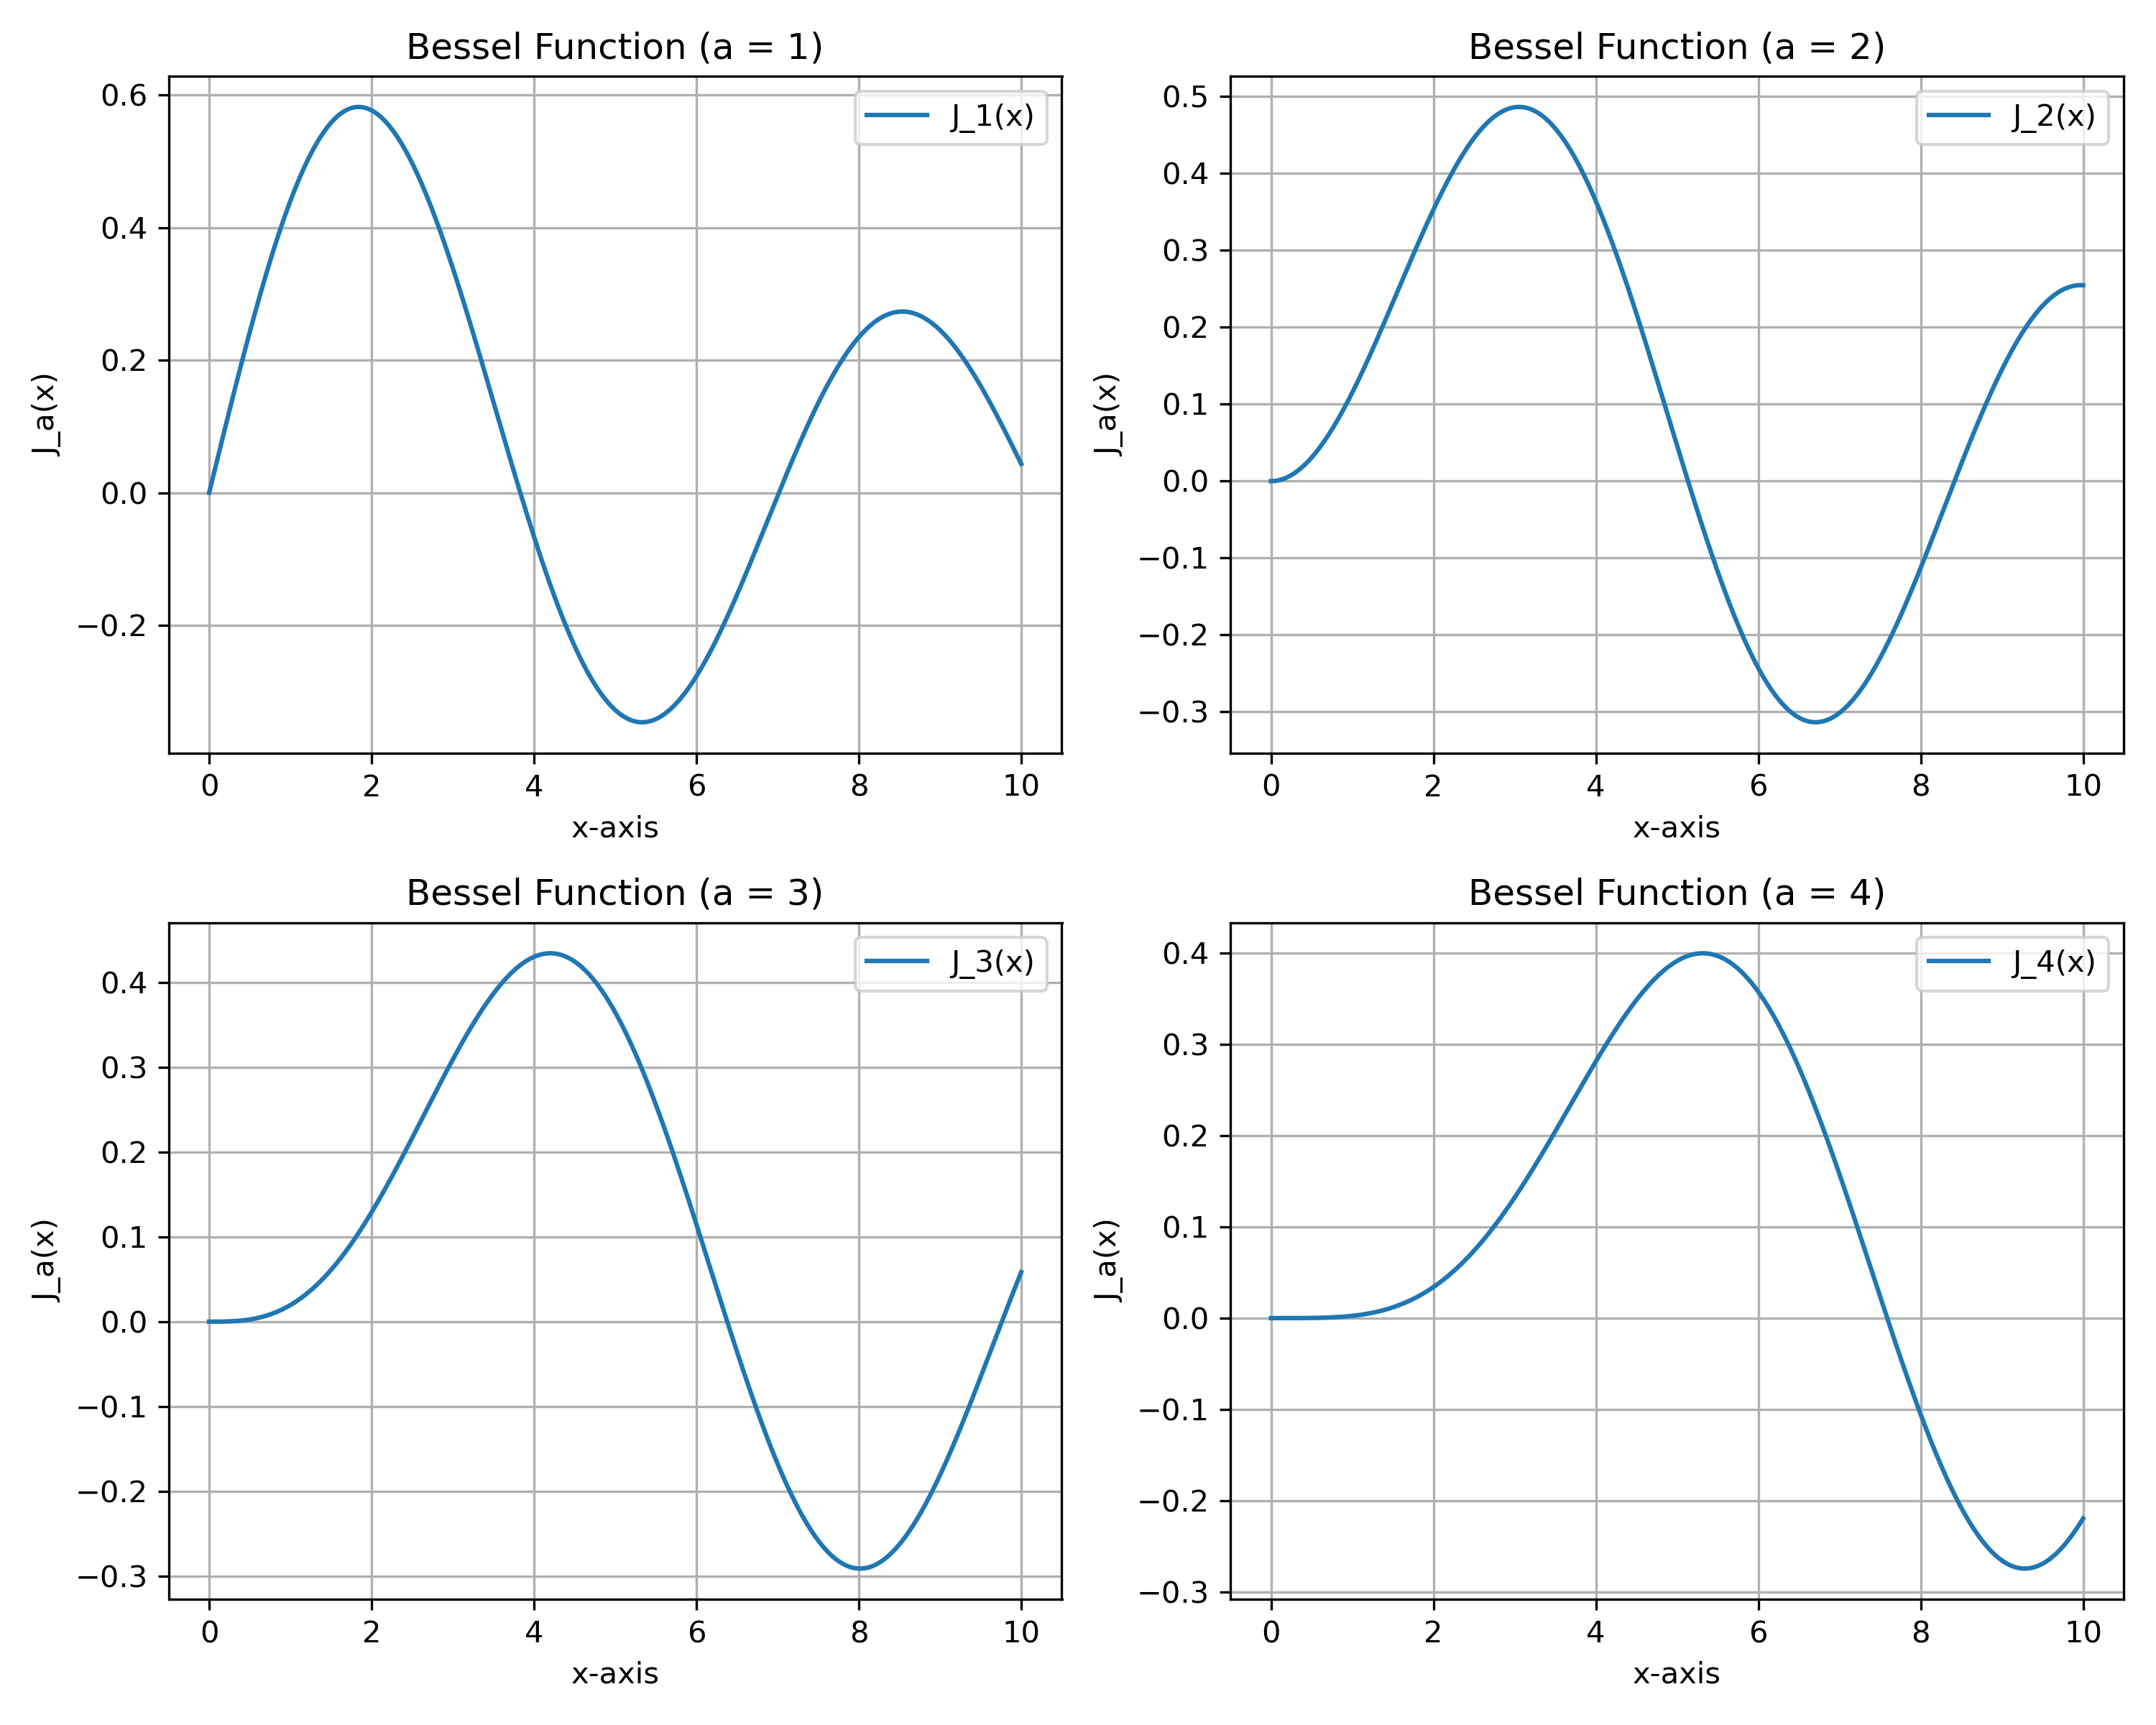

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

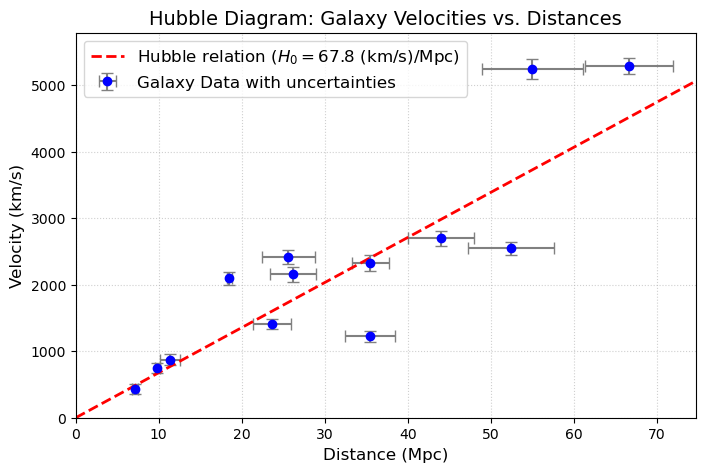

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Provided data as a flat list
data = [
    18.49, 2094.75, 0.3, 100,
    35.48, 2320.87, 2.2, 120,
    35.48, 1224.9, 3.0, 80,
    11.34, 872.13, 1.2, 80,
    7.12, 432.2, 0.4, 70,
    9.82, 751, 0.3, 75,
    23.66, 1410, 2.3, 70,
    44, 2700, 4.0, 110,
    66.7, 5292, 5.3, 120,
    52.4, 2550, 5.2, 100,
    55, 5253, 6.1, 150,
    25.6, 2419, 3.2, 110,
    26.19, 2158, 2.8, 110
]

# Unpack data into separate variables
distances = np.array(data[::4])
velocities = np.array(data[1::4])
error_distances = np.array(data[2::4])
error_velocities = np.array(data[3::4])

# Hubble constant (H_0)
H_0 = 67.8

# Hubble relation function
def hubble_relation(d, H_0):
    return H_0 * d

# Create plot using the object-oriented OO interface of Matplotlib
fig, ax = plt.subplots(figsize=(8, 5))

# Plot data points with error bars 
ax.errorbar(distances, velocities, xerr=error_distances, yerr=error_velocities,
            fmt='o', color='blue', label='Galaxy Data with uncertainties',
            capsize=4, ecolor='gray', markersize=6)

# Plot the theoretical Hubble relation line

d_line = np.linspace(0, max(distances) + 10, 100)
v_line = hubble_relation(d_line, H_0)

# Add value of H_0 to the legend using LaTeX 

label_text = f'Hubble relation ($H_0 = {H_0}$ (km/s)/Mpc)'
ax.plot(d_line, v_line, color='red', linestyle='--', linewidth=2, label=label_text)

# Set labels and title

ax.set_xlabel('Distance (Mpc)', fontsize=12)
ax.set_ylabel('Velocity (km/s)', fontsize=12)
ax.set_title('Hubble Diagram: Galaxy Velocities vs. Distances', fontsize=14)

ax.legend(loc='upper left', fontsize=12)

ax.grid(True, linestyle=':', alpha=0.6)   # Add grid lines

ax.set_xlim(0, max(distances) + 8)    # Set axis limits
ax.set_ylim(0, max(velocities) + 500)

plt.show()


In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
